- Entrada: `data/processed/train.csv`, `roles_columnas.json` y los cinco folds guardados por `03_separacion_datos.ipynb`. `test.csv` se lee después de elegir modelo y umbral.
- Salida: tablas de validación y test en `reports/metrics/`, figuras en `reports/figures/`, predicciones en `data/processed/` y pipeline en `models/modelo_tp1.joblib`.
- Aquí se **preparan las entradas, comparan modelos y evalúan los errores** para anticipar desaprobación o retiro en capacitaciones con evaluación.

Se completan los puntos 6–9 del enunciado y se sintetizan hallazgos y pendientes del punto 10. El enfoque sigue las diapositivas de semanas 3, 5 y 6. Ejecutar antes los notebooks 02 y 03. Todo el código de preparación, entrenamiento y evaluación está en las celdas de este notebook.

## 1. Importar herramientas y cargar train

Pregunta: **¿con qué datos se entrenará y qué información queda reservada?**

Un pipeline aprende mediana, escalas, categorías y clasificador en cada **fold de entrenamiento**. Los grupos de validación solo reciben `transform` y `predict_proba`; no se codifica el dataset completo antes de separar.

**Decisión:** leer únicamente train y sus roles al comenzar; conservar el test para la evaluación de la decisión fijada. El pipeline aprenderá sus transformaciones dentro de cada entrenamiento.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, roc_curve

ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
            if (p / "data").is_dir() and (p / "src").is_dir())
from pathlib import Path
import json
import platform
import joblib
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, make_scorer, precision_recall_curve,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import PredefinedSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
SEMILLA = 42
NUMERICAS = ["HORAS_ACADEMICAS", "MES_INICIO", "ANIO_INICIO"]
METRICAS = ["accuracy", "precision", "recall", "f1", "balanced_accuracy", "ap", "roc_auc"]

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)
FIGURAS = ROOT / "reports" / "figures"
FIGURAS.mkdir(parents=True, exist_ok=True)
def guardar_figura(nombre):
    plt.savefig(FIGURAS / nombre, dpi=150, bbox_inches="tight")

def cargar_train(root):
    """Leer solo train y comprobar los folds; test se lee después de decidir."""
    carpeta = Path(root) / "data" / "processed"
    train = pd.read_csv(carpeta / "train.csv", encoding="utf-8-sig")
    roles = json.loads((carpeta / "roles_columnas.json").read_text(encoding="utf-8"))
    predictoras = roles["predictoras_candidatas"]
    prohibidas = {"y", "FOLD", "EDICION", "ESTADO_CAPACITACION", "DURACION_DIAS",
                  "TERMINO", "FECHA_TERMINO_CORREGIDA", "HORAS_ATIPICA", "DURACION_ATIPICA"}
    assert not set(predictoras) & prohibidas, "Una predictora contiene información prohibida"
    assert set(train["y"].unique()) == {0, 1}
    assert set(train["FOLD"].unique()) == set(range(5)), "Se esperan los cinco folds del notebook 03"
    assert train.groupby("EDICION")["FOLD"].nunique().eq(1).all()
    assert train.groupby("FOLD")["y"].agg(["min", "max"]).eq([0, 1]).all().all()
    X = train[predictoras].copy()
    y = train["y"].astype(int)
    categorias = [c for c in predictoras if c not in NUMERICAS]
    # Conversión determinista de representación, sin aprender estadísticas.
    X[categorias] = X[categorias].astype(object).where(X[categorias].notna(), np.nan)
    cv = list(PredefinedSplit(train["FOLD"].to_numpy()).split())
    return train, X, y, categorias, cv

train, X, y, categoricas, cv = cargar_train(ROOT)
print(f"Train: {len(train):,} participaciones; {train['EDICION'].nunique()} ediciones; riesgo {y.mean():.2%}")
display(pd.DataFrame({"columna": X.columns, "tipo": X.dtypes.astype(str).values,
                      "faltantes": X.isna().sum().values}))
display(train.groupby("FOLD").agg(registros=("y", "size"), positivos=("y", "sum")))

Train: 29,336 participaciones; 158 ediciones; riesgo 5.91%


,columna,tipo,faltantes
0,DEPARTAMENTO,object,0
1,SEXO,object,0
2,NIVEL_GOBIERNO,object,0
3,TRABAJA_ENTIDAD_PUBLICA,object,0
4,TIPO_CAPACITACION,object,0
5,MODALIDAD,object,0
6,TIPO_CONVOCATORIA,object,0
7,HORAS_ACADEMICAS,float64,0
8,MES_INICIO,int64,0
9,ANIO_INICIO,int64,0


,registros,positivos
FOLD,,
0,5851,342
1,5891,346
2,5784,359
3,5930,354
4,5880,334


## 2. Qué hay que decidir y parámetros

| # | Decisión | Qué se hace | Dónde |
|---|---|---|---|
| 1 | ¿Cómo preparar numéricas y categorías? | Mediana, escalado para logística y one-hot dentro del pipeline | Bloque 1 |
| 2 | ¿Con qué referencia y modelos comparar? | Dummy mayoritario, regresión logística, árbol y random forest | Bloque 2 |
| 3 | ¿Cómo comparar sin usar el test? | Cinco folds por edición guardados; métricas, media y dispersión | Bloque 3 |
| 4 | ¿Cómo elegir modelo y umbral? | Mayor AP media para el modelo; máximo F1 OOF para el umbral | Bloques 3 y 4 |
| 5 | ¿Qué significan los errores? | Matrices, casos detectados/omitidos, falsas alertas y segmentos | Bloque 5 |
| 6 | ¿Cómo conservar la evidencia? | Tablas, configuración, predicciones y pipeline exportado | Bloque 6 |
| 7 | ¿Qué queda pendiente para TF1? | Limitaciones, calibración, validación y política de alertas | Bloque 7 |

**Parámetros fijados antes de leer test:** semilla 42; logística `C=1` y `max_iter=2000`; árbol con profundidad 6 y mínimo 50 registros por hoja; forest con 150 árboles, profundidad 10 y mínimo 20 registros por hoja. Los modelos reales utilizan pesos de clase. No se cambia la distribución de validación/test.

La comparación inicial usa umbral 0.5. El umbral elegido con OOF se fija más adelante. Estos parámetros se definen en `construir_modelos`, en la celda del bloque 2 de este notebook.

# BLOQUE 1 - PREPROCESAMIENTO REPRODUCIBLE

## 3. Preparar numéricas y categóricas

Pregunta: **¿cómo convertir las diez predictoras en entradas numéricas sin ajustar la preparación con validación o test?**

- **Numéricas:** horas, mes y año de inicio. `SimpleImputer(strategy="median")` conserva extremos válidos y puede completar faltantes. `StandardScaler` se usa para la regresión logística; los árboles no lo requieren.
- **Categóricas:** `SimpleImputer` con categoría `SIN_DATO` y `OneHotEncoder(handle_unknown="ignore")`. No se asigna un orden artificial a modalidad o departamento; una categoría nueva no provoca un error.
- `ColumnTransformer(remainder="drop")` selecciona expresamente las predictoras. El objetivo, `FOLD`, edición, estado final, nombre y banderas de calidad no entran al modelo.

Actualmente no hay faltantes en las predictoras. La imputación sigue dentro del pipeline y se ajusta solo con train; no se inventan faltantes ni se cambian resultados para justificarla.

La limpieza administrativa del notebook 02 precede al split: sus reglas de representación y población ya estaban fijadas. Algunas decisiones exploratorias (variante más frecuente, selección de columnas y población inferida de estados) usaron el dataset completo. Esto limita la independencia de la evaluación y se documenta; el pipeline controla el ajuste estadístico del **modelamiento**, no borra esas decisiones previas.

**Decisión:** organizar las ramas con ColumnTransformer y unir preparación y clasificador con Pipeline. Medianas, escalas y categorías se aprenden con cada parte de entrenamiento.

In [2]:
def preprocesador(categorias, escalar):
    pasos_num = [("imputar", SimpleImputer(strategy="median", keep_empty_features=True))]
    if escalar:
        pasos_num.append(("escalar", StandardScaler()))
    cat = Pipeline([
        ("imputar", SimpleImputer(strategy="constant", fill_value="SIN_DATO", keep_empty_features=True)),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])
    return ColumnTransformer([
        ("numericas", Pipeline(pasos_num), NUMERICAS),
        ("categoricas", cat, categorias),
    ], remainder="drop")

# BLOQUE 2 - BASELINE Y MODELOS PRELIMINARES

## 4. Construir el baseline y las alternativas

Pregunta: **¿los modelos aportan algo frente a predecir siempre la clase mayoritaria?**

| Modelo | Justificación | Control de complejidad |
|---|---|---|
| Dummy mayoritario | Referencia trivial: siempre sin riesgo | No aprende relaciones |
| Regresión logística | Referencia lineal, sencilla de analizar | Regularización L2, `C=1` |
| Árbol de decisión | Reglas e interacciones no lineales | Profundidad 6, mínimo 50 filas por hoja |
| Random forest | Promedia árboles y captura interacciones | 150 árboles, profundidad 10, mínimo 20 filas por hoja |

Los modelos reales utilizan pesos de clase para que los positivos tengan más peso durante el ajuste. No se remuestrea ni se altera la distribución de validación/test. Los scores de modelos ponderados **no se presentan como probabilidades calibradas**.

Esta comparación es preliminar. No se hizo una búsqueda amplia de hiperparámetros; los límites reducen el sobreajuste y permiten ejecutar el trabajo en un equipo personal.

**Decisión:** comparar un DummyClassifier y tres familias vistas en clase con configuraciones fijadas antes del test. Limitar complejidad y ponderar la clase positiva sin remuestrear la evaluación.

In [3]:
def construir_modelos(categorias):
    """Configuraciones preliminares fijadas antes de consultar el test."""
    candidatos = {
        "Dummy mayoritario": (DummyClassifier(strategy="most_frequent"), False),
        "Regresión logística": (LogisticRegression(
            C=1.0, class_weight="balanced", solver="lbfgs", max_iter=2000,
            random_state=SEMILLA), True),
        "Árbol de decisión": (DecisionTreeClassifier(
            max_depth=6, min_samples_leaf=50, class_weight="balanced",
            random_state=SEMILLA), False),
        "Random forest": (RandomForestClassifier(
            n_estimators=150, max_depth=10, min_samples_leaf=20,
            class_weight="balanced_subsample", random_state=SEMILLA,
            n_jobs=2), False),
    }
    return {nombre: Pipeline([("preparar", preprocesador(categorias, escala)),
                              ("clasificar", modelo)])
            for nombre, (modelo, escala) in candidatos.items()}

modelos = construir_modelos(categoricas)
for nombre, pipeline in modelos.items():
    print(f"\n{nombre}")
    print(pipeline.named_steps["clasificar"])
print("\nEjemplo de preprocesador:")
print(modelos["Regresión logística"].named_steps["preparar"])


Dummy mayoritario
DummyClassifier(strategy='most_frequent')

Regresión logística
LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

Árbol de decisión
DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=50, random_state=42)

Random forest
RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       min_samples_leaf=20, n_estimators=150, n_jobs=2,
                       random_state=42)

Ejemplo de preprocesador:
ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputar',
                                                  SimpleImputer(keep_empty_features=True,
                                                                strategy='median')),
                                                 ('escalar',
                                                  StandardScaler())]),
                                 ['HORAS_ACADEMICAS', 'MES_IN

El baseline siempre responde «sin riesgo»: permitirá ver que una accuracy alta puede coexistir con cero casos positivos detectados. Los otros modelos utilizan las mismas predictoras y particiones; el escalado se aplica solo cuando corresponde.

No se declara un ganador todavía: primero hay que comparar los resultados de validación.

# BLOQUE 3 - COMPARACIÓN CON VALIDACIÓN

## 5. Evaluar con los cinco folds guardados

Pregunta: **¿qué resultados obtiene cada modelo en ediciones que no utilizó para entrenar?**

Se usa `PredefinedSplit` para respetar la columna `FOLD`; pasar simplemente `cv=5` generaría una separación diferente que podría mezclar ediciones.

`cross_validate` entrega métricas de entrenamiento y validación, tiempos y estimadores. Reutilizamos estos estimadores para obtener una predicción **out-of-fold (OOF)** por fila: su modelo no entrenó con esa fila ni con su edición.

Métricas a umbral 0.5: accuracy (contexto), precision (fiabilidad de alertas), recall (riesgo detectado), F1 (equilibrio) y balanced accuracy. Para ranking: ROC-AUC y **AP (Average Precision)**, priorizada por el desbalance. AP resume la curva precision–recall con una suma ponderada; no es el área trapezoidal, por eso se etiqueta explícitamente.

La desviación estándar entre cinco folds describe variabilidad; **no es un intervalo de confianza**. La columna `brecha_ap` compara entrenamiento y validación para investigar sobreajuste.

**Decisión:** usar las mismas cinco particiones para todos los modelos, reportar métricas de entrenamiento/validación y conservar los scores OOF para estudiar el umbral.

In [4]:
def metricas(y, prob, umbral=0.5):
    pred = (np.asarray(prob) >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "accuracy": float(accuracy_score(y, pred)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "ap": float(average_precision_score(y, prob)),
        "roc_auc": float(roc_auc_score(y, prob)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "alertas": int(pred.sum()), "umbral": float(umbral),
    }

def comparar_cv(modelos, X, y, cv):
    scoring = {
        "accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy",
        "precision": make_scorer(precision_score, zero_division=0),
        "recall": make_scorer(recall_score, zero_division=0),
        "f1": make_scorer(f1_score, zero_division=0),
        "ap": "average_precision", "roc_auc": "roc_auc",
    }
    filas, probabilidades = [], {}
    for nombre, pipeline in modelos.items():
        print(f"Evaluando {nombre}: cinco folds por edición", flush=True)
        resultado = cross_validate(
            pipeline, X, y, cv=cv, scoring=scoring,
            return_train_score=True, return_estimator=True,
            error_score="raise", n_jobs=1,
        )
        oof = np.full(len(y), np.nan)
        for fold, (estimador, (_, idx_val)) in enumerate(zip(resultado["estimator"], cv)):
            oof[idx_val] = estimador.predict_proba(X.iloc[idx_val])[:, 1]
            fila = {"modelo": nombre, "fold": fold,
                    "segundos_fit": resultado["fit_time"][fold]}
            for m in METRICAS:
                fila[m] = resultado[f"test_{m}"][fold]
                fila[f"train_{m}"] = resultado[f"train_{m}"][fold]
            filas.append(fila)
        assert np.isfinite(oof).all(), "Faltan predicciones de validación"
        probabilidades[nombre] = oof
    detalle = pd.DataFrame(filas)
    resumen = detalle.groupby("modelo", sort=False)[METRICAS].agg(["mean", "std"])
    resumen.columns = [f"{metrica}_{estad}" for metrica, estad in resumen.columns]
    resumen = resumen.join(detalle.groupby("modelo")["train_ap"].mean())
    resumen["brecha_ap"] = resumen["train_ap"] - resumen["ap_mean"]
    resumen = resumen.sort_values(["ap_mean", "ap_std"], ascending=[False, True])
    return detalle, resumen, probabilidades

detalle, resumen, oof = comparar_cv(modelos, X, y, cv)
display(resumen.round(4))
display(detalle[["modelo", "fold", "train_ap", "ap", "train_f1", "f1", "segundos_fit"]].round(4))

Evaluando Dummy mayoritario: cinco folds por edición
Evaluando Regresión logística: cinco folds por edición
Evaluando Árbol de decisión: cinco folds por edición
Evaluando Random forest: cinco folds por edición


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,ap_mean,ap_std,roc_auc_mean,roc_auc_std,train_ap,brecha_ap
modelo,,,,,,,,,,,,,,,,
Random forest,0.7284,0.1610,0.1428,0.0467,0.5716,0.1401,0.2187,0.0474,0.6548,0.0395,0.1688,0.0316,0.7387,0.0308,0.2396,0.0708
Árbol de decisión,0.7176,0.1576,0.1333,0.0518,0.5303,0.1097,0.2036,0.0578,0.6297,0.0470,0.1506,0.0535,0.6942,0.0585,0.2252,0.0746
Regresión logística,0.7080,0.1549,0.1313,0.0353,0.5995,0.1118,0.2109,0.0450,0.6570,0.0511,0.1410,0.0446,0.7037,0.0967,0.1703,0.0293
Dummy mayoritario,0.9408,0.0019,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0592,0.0019,0.5000,0.0000,0.0591,-0.0000


,modelo,fold,train_ap,ap,train_f1,f1,segundos_fit
0,Dummy mayoritario,0,0.0593,0.0585,0.0000,0.0000,0.1821
1,Dummy mayoritario,1,0.0592,0.0587,0.0000,0.0000,0.1811
2,Dummy mayoritario,2,0.0584,0.0621,0.0000,0.0000,0.1739
3,Dummy mayoritario,3,0.0590,0.0597,0.0000,0.0000,0.1937
4,Dummy mayoritario,4,0.0597,0.0568,0.0000,0.0000,0.2077
5,Regresión logística,0,0.1763,0.1383,0.2045,0.2433,1.1160
6,Regresión logística,1,0.1564,0.1709,0.2252,0.2373,1.1297
7,Regresión logística,2,0.1844,0.0646,0.2260,0.1409,0.8282
8,Regresión logística,3,0.1624,0.1659,0.2190,0.2429,1.2740
9,Regresión logística,4,0.1718,0.1652,0.2108,0.1900,1.3051


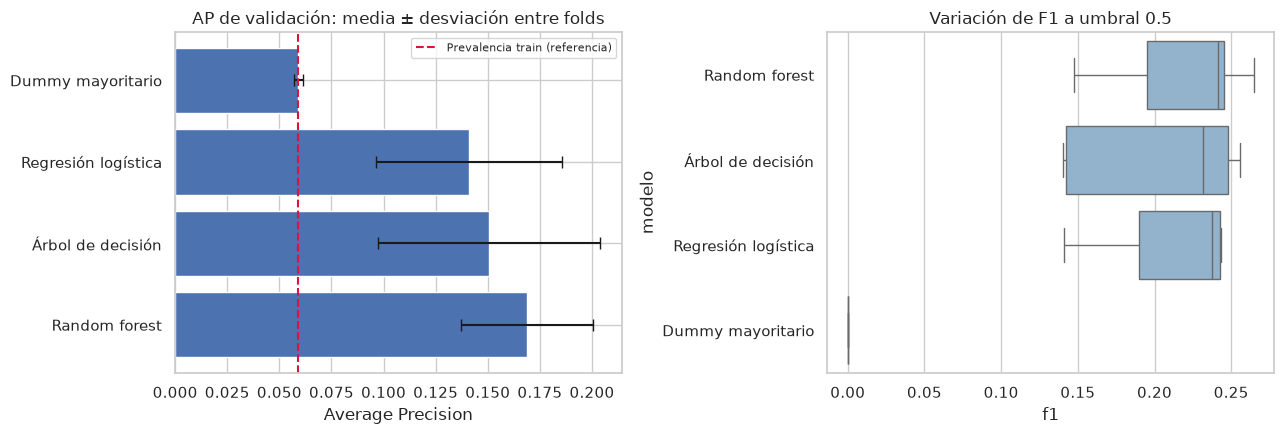

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
orden = list(resumen.index)
axes[0].barh(orden, resumen.loc[orden, "ap_mean"], xerr=resumen.loc[orden, "ap_std"], capsize=4)
axes[0].axvline(y.mean(), color="crimson", ls="--", label="Prevalencia train (referencia)")
axes[0].set_title("AP de validación: media ± desviación entre folds")
axes[0].set_xlabel("Average Precision")
axes[0].legend(fontsize=8)
sns.boxplot(data=detalle, x="f1", y="modelo", ax=axes[1], order=orden, color="#8ab4d6")
axes[1].set_title("Variación de F1 a umbral 0.5")
plt.tight_layout()
guardar_figura("14_comparacion_cv.png")
plt.show()

La tabla y el gráfico muestran la media y variación entre folds. En esta ejecución, la AP media es 0.1688 para forest, 0.1506 para árbol, 0.1410 para logística y 0.0592 para el dummy. Las métricas precision, recall y F1 de esta comparación corresponden a umbral 0.5.

Forest tiene la mayor AP media; logística presenta mayor recall medio a 0.5. Eso muestra que las métricas responden preguntas diferentes. La AP de entrenamiento del forest supera a la de validación en ~0.071: se debe considerar la brecha al discutir generalización.

**Decisión:** priorizar AP media de validación como criterio de elección y mostrar las otras métricas y su dispersión para interpretar el compromiso.

## 6. Ranking, curvas y selección del modelo

Pregunta: **¿qué modelo ordena mejor los casos de riesgo y cómo cambia la detección a distintos niveles de alerta?**

Se fija de antemano: elegir la mayor **AP media de validación** entre los modelos reales; en empate, menor dispersión y después el orden de la tabla. Accuracy no es el criterio de selección.

Las curvas siguientes usan OOF de train y son diagnóstico de desarrollo. La AP global de OOF puede diferir de la media por fold: mezcla scores de cinco modelos y pesos distintos.

**Decisión:** seleccionar entre los modelos reales por AP media, con menor dispersión en caso de empate; utilizar las curvas OOF como diagnóstico de desarrollo.

Modelo elegido sin leer el test: Random forest


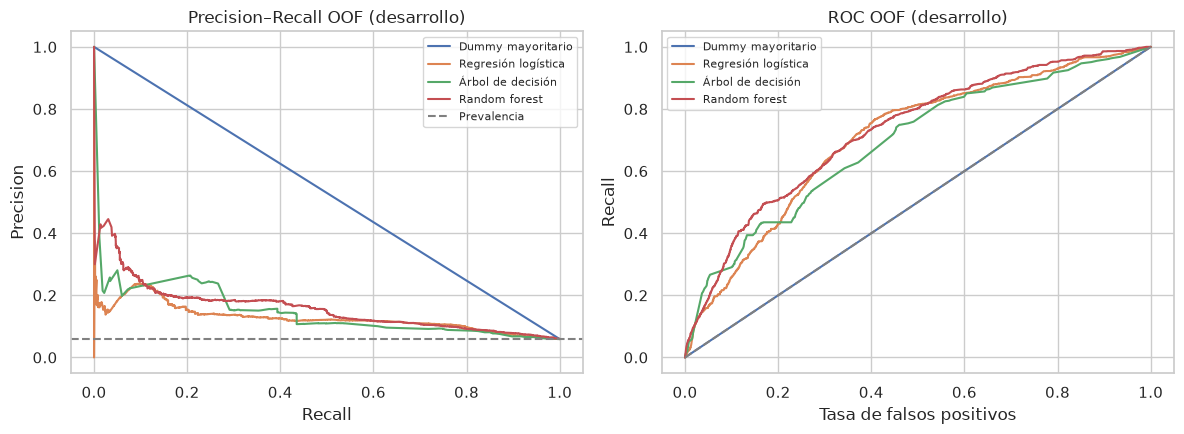

In [6]:
nombre_elegido = resumen.drop(index="Dummy mayoritario").index[0]
prob_oof = oof[nombre_elegido]
print("Modelo elegido sin leer el test:", nombre_elegido)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for nombre, prob in oof.items():
    precision, recall, _ = precision_recall_curve(y, prob)
    axes[0].plot(recall, precision, label=nombre)
    fpr, tpr, _ = roc_curve(y, prob)
    axes[1].plot(fpr, tpr, label=nombre)
axes[0].axhline(y.mean(), ls="--", color="grey", label="Prevalencia")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision–Recall OOF (desarrollo)")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set(xlabel="Tasa de falsos positivos", ylabel="Recall", title="ROC OOF (desarrollo)")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
guardar_figura("15_curvas_oof.png")
plt.show()

Se elige **Random forest** sin leer el test. AP y ROC-AUC evalúan el ranking de los scores; no son el porcentaje de aciertos de las alertas. Un mejor ranking no garantiza que cualquier umbral produzca una política útil de seguimiento.

La siguiente decisión es el límite a partir del cual se generará una alerta.

# BLOQUE 4 - UMBRAL DE ALERTA

## 7. Equilibrar detección y falsas alertas

Pregunta: **¿qué límite del score se usará para generar una alerta sin elegirlo con test?**

Un falso negativo es un participante que desaprueba o se retira sin ser alertado. Un falso positivo recibiría un seguimiento que no necesitaba. No conocemos el costo monetario ni la capacidad de acompañamiento de SERVIR.

Para el TP1 adoptamos un criterio de desarrollo explícito: **máximo F1 en OOF** del modelo elegido. Se compara con 0.5 y se congela antes de leer el test. F1 no equivale a una función de costos; un umbral operativo necesitará validación institucional.

Como estas etiquetas OOF también se usan para elegir modelo y umbral, la métrica ajustada es optimista como estimación de desempeño. **No es una validación independiente ni CV anidada**. El test posterior evalúa la decisión congelada. En TF1 se propone validación anidada y temporal.

**Decisión:** maximizar F1 con scores OOF de train, fijar el umbral y compararlo con 0.5. La métrica OOF ajustada es desarrollo y no se presenta como evaluación independiente.

Umbral fijado con train OOF: 0.639369


,accuracy,precision,recall,f1,balanced_accuracy,ap,roc_auc,tn,fp,fn,tp,alertas,umbral
regla,,,,,,,,,,,,,
0.5,0.7295,0.1212,0.5718,0.2000,0.6556,0.1589,0.7285,20410,7191,743,992,8183,0.5000
máximo F1 OOF (desarrollo),0.8569,0.1820,0.4063,0.2514,0.6458,0.1589,0.7285,24433,3168,1030,705,3873,0.6394


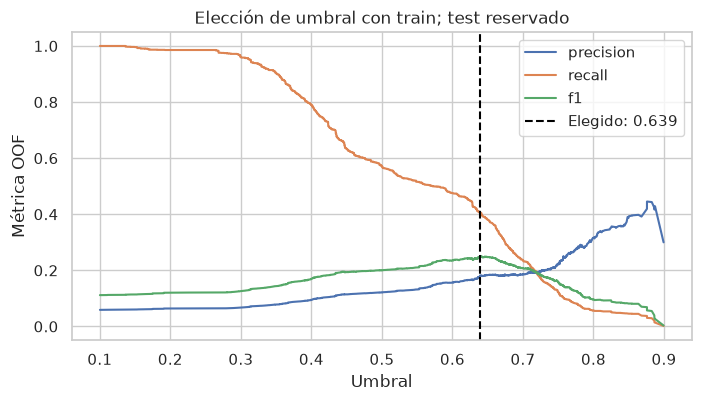

In [7]:
def seleccionar_umbral(y, prob):
    """Maximizar F1 en OOF; estas métricas son de desarrollo, no una prueba nueva."""
    precision, recall, thresholds = precision_recall_curve(y, prob)
    f1 = np.divide(2 * precision[:-1] * recall[:-1], precision[:-1] + recall[:-1],
                   out=np.zeros_like(thresholds), where=(precision[:-1] + recall[:-1]) > 0)
    tabla = pd.DataFrame({"umbral": thresholds, "precision": precision[:-1],
                          "recall": recall[:-1], "f1": f1})
    # Desempate: más recall; después mayor umbral para un resultado determinista.
    mejor = tabla.sort_values(["f1", "recall", "umbral"], ascending=[False, False, False]).iloc[0]
    return float(mejor["umbral"]), tabla

umbral, tabla_umbral = seleccionar_umbral(y, prob_oof)
print(f"Umbral fijado con train OOF: {umbral:.6f}")
desarrollo = pd.DataFrame([
    {"regla": "0.5", **metricas(y, prob_oof, 0.5)},
    {"regla": "máximo F1 OOF (desarrollo)", **metricas(y, prob_oof, umbral)},
]).set_index("regla")
display(desarrollo.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
for m in ["precision", "recall", "f1"]:
    ax.plot(tabla_umbral["umbral"], tabla_umbral[m], label=m)
ax.axvline(umbral, ls="--", color="black", label=f"Elegido: {umbral:.3f}")
ax.set(xlabel="Umbral", ylabel="Métrica OOF", title="Elección de umbral con train; test reservado")
ax.legend()
guardar_figura("16_umbral_oof.png")
plt.show()

El umbral elegido en esta ejecución es **0.639369**. Un score igual o mayor genera alerta; un score menor no la genera. Ese número es un límite técnico, no una probabilidad absoluta de riesgo.

**Decisión:** congelar modelo y umbral antes de abrir test. No conocemos los costos de cada error ni la capacidad de acompañamiento de SERVIR; el límite operativo deberá validarse para TF1.

# BLOQUE 5 - EVALUACIÓN FINAL Y ANÁLISIS DE ERRORES

## 8. Evaluar la decisión fijada en test

Pregunta: **¿qué detecta y qué errores produce la solución elegida en las participaciones reservadas?**

Recién aquí se carga `test.csv`. Se ajusta el pipeline seleccionado con todo train y se evalúa el baseline, la referencia de umbral 0.5 y el umbral congelado. No se prueban otros modelos para cambiar la selección después de ver test.

AP/ROC-AUC no cambian al variar el umbral; dependen del ranking. Precision, recall, F1 y la matriz sí cambian.

**Decisión:** entrenar el pipeline elegido con todo train y evaluar baseline, referencia 0.5 y umbral OOF fijado. Mostrar ambos umbrales sin cambiar la selección después de observar test.

,accuracy,precision,recall,f1,balanced_accuracy,ap,roc_auc,tn,fp,fn,tp,alertas,umbral
evaluacion,,,,,,,,,,,,,
Dummy mayoritario,0.9408,0.0000,0.0000,0.0000,0.5000,0.0592,0.500,6910,0,435,0,0,0.5000
Random forest · umbral 0.5,0.8181,0.1757,0.5609,0.2675,0.6976,0.2217,0.831,5765,1145,191,244,1389,0.5000
Random forest · umbral OOF,0.8715,0.1988,0.3862,0.2625,0.6441,0.2217,0.831,6233,677,267,168,845,0.6394


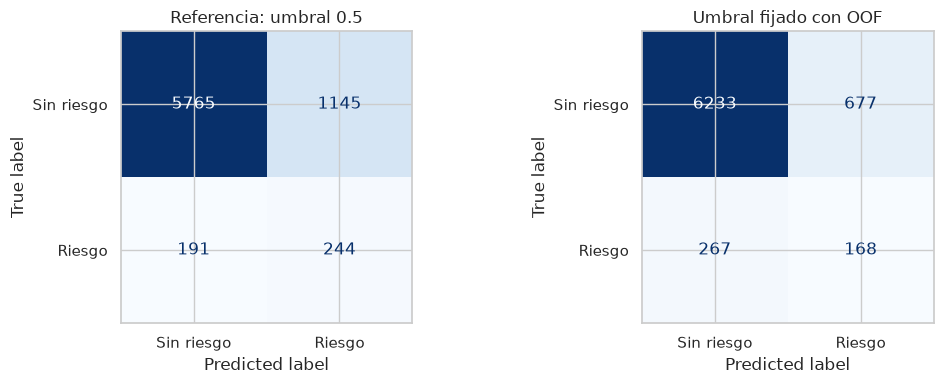

In [8]:
def evaluar_test(root, train, X, y, modelos, nombre, umbral):
    test = pd.read_csv(Path(root) / "data/processed/test.csv", encoding="utf-8-sig")
    assert set(train["EDICION"]).isdisjoint(set(test["EDICION"]))
    X_test = test[X.columns].copy()
    cats = [c for c in X.columns if c not in NUMERICAS]
    X_test[cats] = X_test[cats].astype(object).where(X_test[cats].notna(), np.nan)
    y_test = test["y"].astype(int)
    final = clone(modelos[nombre]).fit(X, y)
    prob = final.predict_proba(X_test)[:, 1]
    dummy = clone(modelos["Dummy mayoritario"]).fit(X, y)
    prob_dummy = dummy.predict_proba(X_test)[:, 1]
    resultados = pd.DataFrame([
        {"evaluacion": "Dummy mayoritario", **metricas(y_test, prob_dummy)},
        {"evaluacion": f"{nombre} · umbral 0.5", **metricas(y_test, prob)},
        {"evaluacion": f"{nombre} · umbral OOF", **metricas(y_test, prob, umbral)},
    ]).set_index("evaluacion")
    pred = (prob >= umbral).astype(int)
    diagnostico = test[["EDICION", "NOMBRE_CAPACITACION", "SEXO", "NIVEL_GOBIERNO",
                       "TIPO_CAPACITACION", "DEPARTAMENTO", "ESTADO_CAPACITACION", "y"]].copy()
    diagnostico["score_riesgo"] = prob
    diagnostico["prediccion"] = pred
    diagnostico["resultado"] = np.select(
        [(y_test == 1) & (pred == 1), (y_test == 0) & (pred == 1),
         (y_test == 1) & (pred == 0)], ["TP", "FP", "FN"], default="TN")
    segmentos = []
    for columna in ["SEXO", "NIVEL_GOBIERNO", "TIPO_CAPACITACION"]:
        for grupo, sub in diagnostico.groupby(columna):
            tn, fp, fn, tp = confusion_matrix(sub["y"], sub["prediccion"], labels=[0, 1]).ravel()
            segmentos.append({"variable": columna, "grupo": grupo, "n": len(sub),
                              "positivos": int(tp + fn), "tp": int(tp), "fp": int(fp),
                              "fn": int(fn), "tn": int(tn),
                              "recall": tp / (tp + fn) if tp + fn else np.nan,
                              "precision": tp / (tp + fp) if tp + fp else np.nan,
                              "fpr": fp / (fp + tn) if fp + tn else np.nan})
    return final, test, prob, resultados, diagnostico, pd.DataFrame(segmentos)

modelo_final, test, prob_test, resultados_test, diagnostico, segmentos = evaluar_test(
    ROOT, train, X, y, modelos, nombre_elegido, umbral
)
display(resultados_test.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, threshold, titulo in zip(axes, [0.5, umbral], ["Referencia: umbral 0.5", "Umbral fijado con OOF"]):
    ConfusionMatrixDisplay.from_predictions(
        test["y"], (prob_test >= threshold).astype(int), labels=[0, 1],
        display_labels=["Sin riesgo", "Riesgo"], ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(titulo)
plt.tight_layout()
guardar_figura("17_matrices_test.png")
plt.show()

In [9]:
fila = resultados_test.iloc[-1]
dummy = resultados_test.iloc[0]
display(Markdown(
    f"**Lectura del test:** {nombre_elegido}, umbral {umbral:.3f}. "
    f"De {int(test['y'].sum())} casos de riesgo, se detectaron **{int(fila.tp)}** "
    f"y se omitieron **{int(fila.fn)}**. Se generaron **{int(fila.fp)} falsas alertas**. "
    f"Recall {fila.recall:.1%}; precision {fila.precision:.1%}; F1 {fila.f1:.3f}. "
    f"AP {fila.ap:.3f}, frente a {dummy.ap:.3f} del baseline. "
    "El resultado describe este test; no demuestra utilidad institucional ni causalidad."
))

**Lectura del test:** Random forest, umbral 0.639. De 435 casos de riesgo, se detectaron **168** y se omitieron **267**. Se generaron **677 falsas alertas**. Recall 38.6%; precision 19.9%; F1 0.263. AP 0.222, frente a 0.059 del baseline. El resultado describe este test; no demuestra utilidad institucional ni causalidad.

Con el umbral OOF, se detectan **168 de 435** casos de riesgo, se omiten **267** y se generan **677** falsas alertas. Recall = 38.62 %, precision = 19.88 % y F1 = 0.2625. El modelo tiene señal predictiva, pero la detección sigue siendo limitada y hay una carga considerable de seguimiento.

A umbral 0.5 se detectan 244 casos y se producen 1 145 falsas alertas, con F1 = 0.2675. El umbral seleccionado reduce las falsas alertas, pero no mejora F1 en este test.

**Decisión:** conservar el resultado y documentar esa limitación; no escoger retrospectivamente un umbral a partir de la prueba final.

## 9. Revisar errores por edición y segmento

Pregunta: **¿en qué grupos y capacitaciones se concentran las falsas alertas y los casos omitidos?**

Se muestra recall, precision y tasa de falsos positivos por sexo, nivel de gobierno y tipo de capacitación. Un grupo pequeño o con pocos positivos produce métricas inestables. `NaN` significa que no existe el denominador necesario; no se interpreta como cero.

Las diferencias observadas no prueban discriminación ni ausencia de sesgo. La composición de cursos y el régimen de evaluación pueden explicar parte de ellas. No se reentrena ni se modifica el umbral con este diagnóstico del test.

**Decisión:** usar los segmentos y ediciones para describir limitaciones, considerando tamaños y positivos disponibles. No ajustar el modelo o el umbral con este diagnóstico del test.

In [10]:
display(segmentos.round(4))
display(diagnostico["resultado"].value_counts().rename("participaciones").to_frame())
for tipo in ["FP", "FN"]:
    print(f"\nEdiciones con más {tipo}:")
    display(diagnostico.loc[diagnostico["resultado"] == tipo]
            .groupby(["NOMBRE_CAPACITACION", "EDICION"]).size()
            .sort_values(ascending=False).head(5).rename("errores").to_frame())

# La similitud global no implica equivalencia por subgrupo.
composicion = pd.concat([train.assign(conjunto="train"), test.assign(conjunto="test")], ignore_index=True)
display(pd.crosstab(composicion["TIPO_CAPACITACION"], composicion["conjunto"], normalize="columns").round(4))
print("Nombres de curso presentes en ambos lados:",
      len(set(train["NOMBRE_CAPACITACION"]) & set(test["NOMBRE_CAPACITACION"])))


Ediciones con más FP:

Ediciones con más FN:
Nombres de curso presentes en ambos lados: 17


,variable,grupo,n,positivos,tp,fp,fn,tn,recall,precision,fpr
0,SEXO,HOMBRE,3769,222,100,407,122,3140,0.4505,0.1972,0.1147
1,SEXO,MUJER,3576,213,68,270,145,3093,0.3192,0.2012,0.0803
2,NIVEL_GOBIERNO,LOCAL,986,92,41,230,51,664,0.4457,0.1513,0.2573
3,NIVEL_GOBIERNO,NACIONAL,5235,253,67,333,186,4649,0.2648,0.1675,0.0668
4,NIVEL_GOBIERNO,"NO APLICA (PRIVADO, UNIVERSITARIO, LOCADOR, ETC)",314,40,37,53,3,221,0.9250,0.4111,0.1934
5,NIVEL_GOBIERNO,ORGANISMOS AUTÓNOMOS,269,8,0,1,8,260,0.0000,0.0000,0.0038
6,NIVEL_GOBIERNO,REGIONAL,541,42,23,60,19,439,0.5476,0.2771,0.1202
7,TIPO_CAPACITACION,CURSO,2325,14,6,28,8,2283,0.4286,0.1765,0.0121
8,TIPO_CAPACITACION,CURSO MOOC,3909,223,0,1,223,3685,0.0000,0.0000,0.0003
9,TIPO_CAPACITACION,MICROCURSO,191,9,9,182,0,0,1.0000,0.0471,1.0000


,participaciones
resultado,
TN,6233
FP,677
FN,267
TP,168


errores
NOMBRE_CAPACITACION                                                    EDICION                                                                        
INTELIGENCIA ARTIFICIAL PARA LA DIRECCIÓN PÚBLICA: COMUNICACIÓN EST... INTELIGENCIA ARTIFICIAL PARA LA DIRECCIÓN PÚBLICA: COMUNICACIÓN EST...      176
                                                                       INTELIGENCIA ARTIFICIAL PARA LA DIRECCIÓN PÚBLICA: COMUNICACIÓN EST...       85
DESCIFRANDO LA LÓGICA DEL MARCO LÓGICO                                 DESCIFRANDO LA LÓGICA DEL MARCO LÓGICO | 20251001 | 20251228 | E-LE...       66
DIFERENCIA ENTRE GOBIERNO ELECTRÓNICO, GOBIERNO DIGITAL Y TRANSFORM... DIFERENCIA ENTRE GOBIERNO ELECTRÓNICO, GOBIERNO DIGITAL Y TRANSFORM...       54
XXIV PROGRAMA DE EXTENSIÓN UNIVERSITARIA (PEU) OSINERGMIN-REGULACIÓ... XXIV PROGRAMA DE EXTENSIÓN UNIVERSITARIA (PEU) OSINERGMIN-REGULACIÓ...       53

,,errores
NOMBRE_CAPACITACION,EDICION,
TRANSFORMACIÓN DIGITAL EN EL PERÚ,TRANSFORMACIÓN DIGITAL EN EL PERÚ | 20250217 | 20251123 | E-LEARNING_MOOC,198
HABILIDADES Y COMPETENCIAS PARA LA MUJER EJECUTIVA EN EL SECTOR PÚBLICO,HABILIDADES Y COMPETENCIAS PARA LA MUJER EJECUTIVA EN EL SECTOR PÚBLICO | 20250407 | 20250806 | B-LEARNING,16
NEGOCIACIÓN COLECTIVA EN EL SECTOR PÚBLICO,NEGOCIACIÓN COLECTIVA EN EL SECTOR PÚBLICO | 20260418 | 20260418 | PRESENCIAL,10
"NORMAS, TRANSPARENCIA Y LIDERAZGO ÉTICO PARA LA LUCHA CONTRA LA CORRUPCIÓN EN EL PERÚ","NORMAS, TRANSPARENCIA Y LIDERAZGO ÉTICO PARA LA LUCHA CONTRA LA CORRUPCIÓN EN EL PERÚ | 20251006 | 20251209 | E-LEARNING_CONVENCIONAL",8
GESTIÓN PÚBLICA CON ENFOQUE INTERCULTURAL,GESTIÓN PÚBLICA CON ENFOQUE INTERCULTURAL | 20260224 | 20260322 | E-LEARNING_MOOC,8


conjunto,test,train
TIPO_CAPACITACION,,
CURSO,0.3165,0.0554
CURSO MOOC,0.5322,0.6279
INNOVATHON,0.0000,0.0022
MICROCURSO,0.0260,0.0286
PROGRAMA,0.0169,0.1906
TALLER,0.1084,0.0954


Las tablas muestran los casos y errores por grupo, además de las ediciones con más FP/FN. Hay **17 nombres de capacitación** presentes en train y test: las ediciones no se comparten, pero algunos cursos sí se repiten.

La mezcla de tipos también cambia: CURSO representa ~5.5 % de train y ~31.7 % de test; PROGRAMA, ~19.1 % y ~1.7 %. Una tasa global de riesgo similar no garantiza la misma composición ni dificultad por segmento.

**Decisión:** presentar estas diferencias como límites de la evaluación; no afirmar estabilidad en grupos pequeños ni ausencia de sesgo solo por estas tablas.

## 10. Interpretar las entradas del modelo

Pregunta: **¿qué columnas transformadas utiliza con mayor peso el clasificador ajustado?**

Los coeficientes o importancias describen el modelo ajustado; no son efectos causales. En forest/árbol se muestran importancias por reducción de impureza, que pueden favorecer variables con más posibilidades de corte. En regresión logística los signos se leen respecto de una representación one-hot regularizada; categorías y variables correlacionadas impiden atribuir un efecto aislado.

No se usa esta tabla para volver a seleccionar variables a partir del test.

**Decisión:** mostrar importancias o coeficientes para describir el modelo. No atribuir efectos causales ni volver a elegir variables a partir del test.

,importancia_impureza
categoricas__MODALIDAD_E-LEARNING,0.020769
categoricas__TIPO_CONVOCATORIA_CERRADA,0.025264
categoricas__TIPO_CONVOCATORIA_CONCURSO PÚBLICO,0.034613
categoricas__TIPO_CAPACITACION_CURSO MOOC,0.041321
categoricas__MODALIDAD_E-LEARNING_MOOC,0.044286
categoricas__TIPO_CAPACITACION_PROGRAMA,0.052660
categoricas__MODALIDAD_E-LEARNING_CONVENCIONAL,0.054860
categoricas__MODALIDAD_REMOTA,0.063305
categoricas__TIPO_CONVOCATORIA_ABIERTA,0.064116
numericas__ANIO_INICIO,0.073467


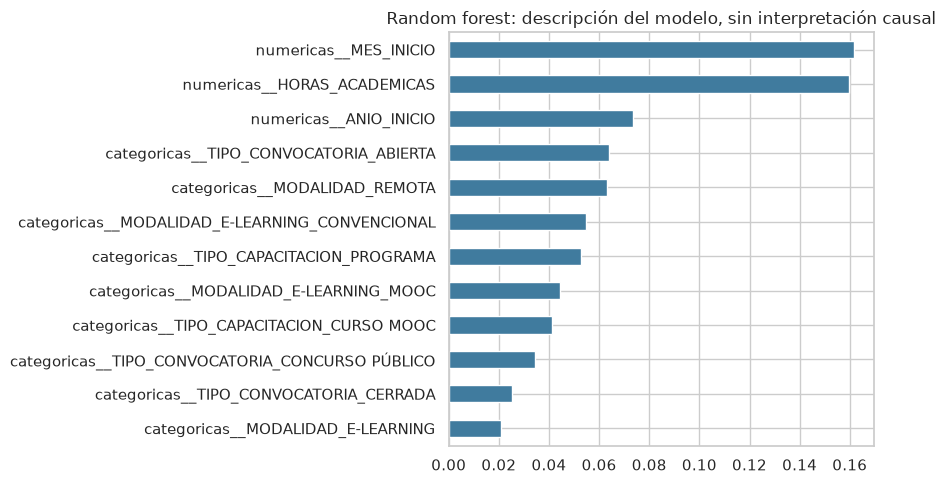

In [11]:
nombres = modelo_final.named_steps["preparar"].get_feature_names_out()
clasificador = modelo_final.named_steps["clasificar"]
if hasattr(clasificador, "feature_importances_"):
    importancia = pd.Series(clasificador.feature_importances_, index=nombres, name="importancia_impureza")
else:
    importancia = pd.Series(clasificador.coef_[0], index=nombres, name="coeficiente")
top = importancia.loc[importancia.abs().nlargest(12).index].sort_values()
display(top.to_frame())
fig, ax = plt.subplots(figsize=(9, 5))
top.plot.barh(ax=ax, color="#407b9e")
ax.set_title(f"{nombre_elegido}: descripción del modelo, sin interpretación causal")
plt.tight_layout()
guardar_figura("18_variables_modelo.png")
plt.show()

# BLOQUE 6 - EVIDENCIA Y GUARDADO

## 11. Guardar tablas, configuración y pipeline

Pregunta: **¿qué archivos permiten verificar y reproducir el resultado?**

Las tablas resumidas quedan en `reports/metrics/`. Las predicciones detalladas quedan en `data/processed/` (ignorada por git). El pipeline se guarda en `models/modelo_tp1.joblib`, junto con umbral y lista de entradas; puede regenerarse y no es necesario versionar el binario.

El archivo exportado recibe **las diez columnas preparadas por las reglas del notebook 02**, no el CSV crudo. No incluye automáticamente la limpieza administrativa ni demuestra un despliegue funcional. Cargar un joblib solo si proviene de una fuente confiable.

**Decisión:** guardar métricas resumidas en reports, predicciones regenerables en data/processed y pipeline con umbral y esquema de entradas en models.

In [12]:
def guardar_resultados(root, detalle, resumen, oof, train, nombre, umbral,
                       tabla_umbral, modelo, resultados, diagnostico, segmentos):
    root = Path(root)
    destino = root / "reports" / "metrics"
    destino.mkdir(parents=True, exist_ok=True)
    detalle.to_csv(destino / "cv_folds.csv", index=False)
    resumen.to_csv(destino / "cv_resumen.csv")
    tabla_umbral.to_csv(destino / "umbrales_oof.csv", index=False)
    resultados.to_csv(destino / "test_metricas.csv")
    segmentos.to_csv(destino / "test_segmentos.csv", index=False)
    # Predicciones detalladas reproducibles, fuera de git como los demás datos.
    diagnostico.to_csv(root / "data/processed/predicciones_test.csv", index=False)
    oof_df = pd.DataFrame(oof)
    oof_df.insert(0, "y", train["y"])
    oof_df.insert(0, "FOLD", train["FOLD"])
    oof_df.to_csv(root / "data/processed/predicciones_oof.csv", index=False)
    versiones = {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
                 "numpy": np.__version__, "pandas": pd.__version__, "joblib": joblib.__version__}
    config = {
        "modelo": nombre, "umbral": umbral, "criterio_modelo": "mayor AP media de CV por edición",
        "criterio_umbral": "máximo F1 de predicciones OOF de train",
        "advertencia": "Umbral y modelo elegidos con validación: OOF ajustada es desarrollo, no evaluación independiente.",
        "semilla": SEMILLA, "predictoras": list(modelo.feature_names_in_),
        "versiones": versiones,
        "parametros_clasificador": modelo.named_steps["clasificar"].get_params(),
        "calibracion": "No calibrado; class_weight y selección de umbral impiden asumir probabilidades calibradas.",
    }
    (destino / "seleccion.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
    (root / "models").mkdir(exist_ok=True)
    joblib.dump({"pipeline": modelo, "umbral": umbral, "predictoras": config["predictoras"]},
                root / "models" / "modelo_tp1.joblib")
    return config

config = guardar_resultados(
    ROOT, detalle, resumen, oof, train, nombre_elegido, umbral, tabla_umbral,
    modelo_final, resultados_test, diagnostico, segmentos,
)
print(json.dumps(config, ensure_ascii=False, indent=2))
print("Evidencia guardada en reports/metrics/; pipeline en models/modelo_tp1.joblib")

{
  "modelo": "Random forest",
  "umbral": 0.6393694426502085,
  "criterio_modelo": "mayor AP media de CV por edición",
  "criterio_umbral": "máximo F1 de predicciones OOF de train",
  "advertencia": "Umbral y modelo elegidos con validación: OOF ajustada es desarrollo, no evaluación independiente.",
  "semilla": 42,
  "predictoras": [
    "DEPARTAMENTO",
    "SEXO",
    "NIVEL_GOBIERNO",
    "TRABAJA_ENTIDAD_PUBLICA",
    "TIPO_CAPACITACION",
    "MODALIDAD",
    "TIPO_CONVOCATORIA",
    "HORAS_ACADEMICAS",
    "MES_INICIO",
    "ANIO_INICIO"
  ],
  "versiones": {
    "python": "3.14.7",
    "scikit-learn": "1.9.1",
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "joblib": "1.6.0"
  },
  "parametros_clasificador": {
    "bootstrap": true,
    "ccp_alpha": 0.0,
    "class_weight": "balanced_subsample",
    "criterion": "gini",
    "max_depth": 10,
    "max_features": "sqrt",
    "max_leaf_nodes": null,
    "max_samples": null,
    "min_impurity_decrease": 0.0,
    "min_samples_leaf": 2

La configuración registra modelo, umbral, criterios de selección, semilla, predictoras, versiones y parámetros. Los CSV permiten revisar los resultados por fold y test. El joblib guarda el pipeline ajustado para reutilizarlo con las diez entradas preparadas.

**Validación:** los cuatro notebooks se ejecutaron sin errores; el pipeline serializado reproduce los scores y métricas guardados. Las pruebas comprueban, entre otros comportamientos, que categorías nuevas y faltantes no reajustan la preparación al predecir.

# BLOQUE 7 - SÍNTESIS Y PLAN HACIA EL TF1

## 12. Hallazgos, limitaciones y siguiente etapa

Pregunta: **¿qué permite concluir este avance y qué falta antes de una aplicación de uso?**

- 36 681 participaciones con evaluación; 2 170 desenlaces positivos. La evaluación no se generaliza automáticamente a las 83 930 filas originales ni a nuevos períodos.
- El régimen de evaluación se infiere de resultados históricos: confirmarlo con metadata disponible al inscribirse.
- La limpieza y el EDA iniciales observaron todo el dataset: el test es reservado para selección de modelos/umbral, pero no es un conjunto externo completamente desconocido.
- Las identidades están enmascaradas: podemos separar por edición, pero no por persona.
- Hay nombres de curso compartidos entre train/test y distinta composición por tipos; se evalúan ediciones nuevas, no exclusivamente cursos nuevos.
- Los scores ponderados no están calibrados; no se comunican como riesgos absolutos individuales.
- OOF usada para selección de umbral es desarrollo. No se ofrece esa F1 como una estimación independiente.
- Cinco folds permiten observar dispersión, sin garantizar estabilidad en producción.
- TF1: validación temporal/anidada, calibración, costos y capacidad de alertas, análisis por segmentos, experimentación registrada y aplicación de uso.

Referencias: diapositivas suministradas de semanas 3, 5 y 6; [ColumnTransformer con tipos mixtos](https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html), [cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html) y [Average Precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).

El cierre de hallazgos y el plan de TF1 están en `docs/plan-hacia-tf1.md`.

**Decisión:** reportar la señal predictiva y los errores con honestidad. Confirmar metadata, mejorar validación, evaluar calibración y definir costos/capacidad de seguimiento antes de uso institucional.

### Lo que se encontró

1. El baseline alcanza ~94 % de accuracy en test sin detectar ningún positivo; esa métrica aislada no responde al objetivo.
2. Forest obtiene la mayor AP media de validación entre las configuraciones comparadas.
3. En test, AP = 0.2217 frente a 0.0592 del dummy; hay cierta capacidad de ordenar riesgo.
4. A umbral 0.639 se detectan 168 casos y hay 677 falsas alertas; la utilidad operativa aún necesita evaluación.
5. Ajustar F1 con OOF no garantizó mejorar F1 en test: se conserva y explica la diferencia.

### Lo que no se puede concluir

- Que el score sea una probabilidad calibrada o una certeza de desaprobación.
- Que las variables importantes causen el resultado.
- Que la solución ya sea útil para SERVIR o que el acompañamiento cambie los desenlaces.
- Que el desempeño se mantenga en cursos, personas o períodos nuevos sin otra evaluación.

### Actividades hacia el TF1

Confirmar régimen de evaluación y variables disponibles al inscribirse; encapsular limpieza desde el CSV crudo; ampliar validación temporal y anidada por grupos; evaluar calibración; registrar experimentos; definir costos y capacidad de alertas; profundizar errores/segmentos y construir una aplicación de uso.

El detalle de hallazgos, problemas pendientes y evidencia esperada está en `docs/plan-hacia-tf1.md`.